> 문제: 테스트 세트를 계속 사용해서 성능을 자꾸 확인하다 보면 점점 테스트 세트에 잘 맞는 모델이 만들어지는 것이 아닌가??

테스트 세트로 일반화 성능을 올바르게 예측하려면 가능한 한 테스트 세트를 사용하지 말아야 한다. 모델을 만들고 나서 마지막에 딱 한 번만 사용하는 것이 좋다.

### 검증 세트
테스트 세트를 사용하지 않고 모델이 과대/과소적합인지 판단하기 위해 훈련세트를 또 나눈다.

훈련세트 중에서 다시 20%를 떼어 내어 검증 세트로 만든다.

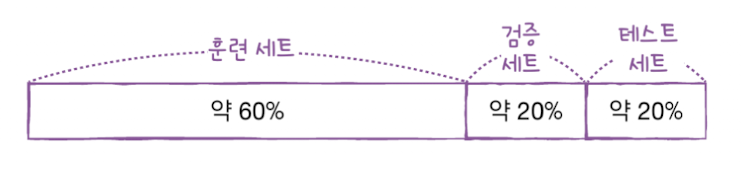

훈련 세트에서 모델을 훈련하고 검증 세트로 모델을 평가한다. 이런 식으로 가장 좋은 모델을 고른 뒤, 훈련세트와 검증세트를 합친 전체 훈련 데이터에서 모델을 다시 훈련한다.

마지막에 테스트 세트에서 최종 점수를 평가한다.

In [1]:
# 데이터 불러오기
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

In [2]:
# 특성과 타깃 열 분리해서 저장
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [3]:
# 훈련/테스트 세트 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [4]:
# 훈련세트 내에서 검증세트 만들기
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [ ]:
# 훈련/검증 세트 크기 확인
print(sub_input.shape, val_input.shape)

(4157, 3) (1040, 3)


훈련세트 4157개, 검증세트 1040개

In [6]:
# 훈련/검증세트를 사용해 모델 만들고 평가
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(sub_input, sub_target)

print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.8692307692307693


이 모델은 확실히 훈련 세트에 과대적합 되어있다!

### 교차 검증 (cross validation)
보통 많은 데이터를 훈련에 사용할 수록 좋은 모델이 만들어지는데, 검증 세트를 만드느라 훈련 세트가 줄어든 상황.

-> 교차검증: 검증 세트를 떼어 내어 평가하는 과정을 여러 번 반복한다. 그 다음 이 점수를 평균해서 최종 검증 점수를 얻는다.

예시) 3-fold 교차 검증

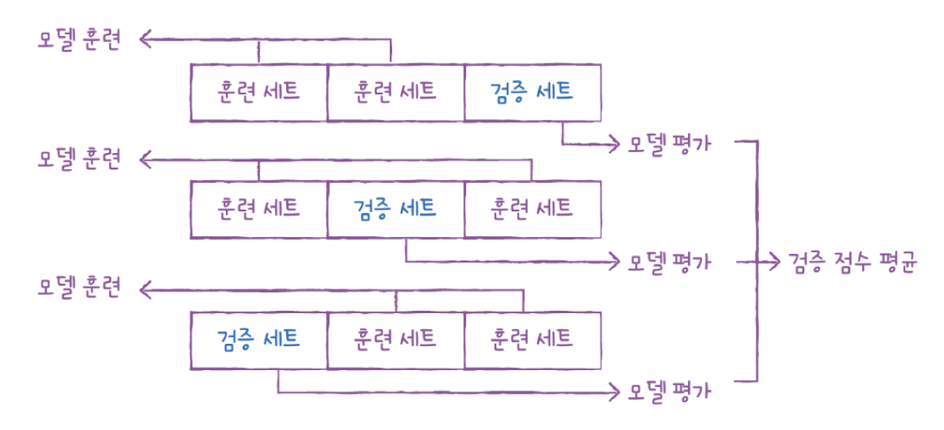

In [7]:
# 교차 검증
from sklearn.model_selection import cross_validate
scores = cross_validate(dt, train_input, train_target)
print(scores)

{'fit_time': array([0.0077486 , 0.00700331, 0.00670958, 0.00774765, 0.00658679]), 'score_time': array([0.00101686, 0.00107312, 0.00076699, 0.00101972, 0.0010643 ]), 'test_score': array([0.87115385, 0.84807692, 0.87487969, 0.85563041, 0.83445621])}


모델 훈련 시간, 모델 검증 시간, 교차 검증 점수 차례로 반환한다.

기본적으로 5-fold 교차 검증을 수행한다.

In [ ]:
# 교차 검증의 최종 점수: 5개 점수의 평균
import numpy as np
print(np.mean(scores['test_score']))

0.8568394165988005


cross_validate()는 훈련 세트를 섞어 폴드를 나누지 않는다. 

-> 교차 검증을 할 때 훈련 세트를 섞으려면 분할기(splitter)를 지정해야 한다.
* 회귀 모델일 경우 기본적으로 KFold 분할기 사용
* 분류 모델일 경우 타깃 클래스를 골고루 나누기 위해 StratifiedKFold 사용 

In [9]:
# 앞서 수행한 교차 검증은 다음 코드와 동일하다
from sklearn.model_selection import StratifiedKFold
scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
print(np.mean(scores['test_score']))

0.8545319093803213


In [10]:
# 훈련세트를 섞은 후 10-fold 교차 검증을 수행하는 경우
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.854534978508967


### 하이퍼파라미터 튜닝
하이퍼파라미터: 모델이 학습할 수 없어서 사용자가 지정해야만 하는 파라미터

하이퍼파라미터 튜닝 과정
* 라이브러리가 제공하는 기본값 그대로 사용해서 모델 훈련
* 검증 세트의 점수나 교차 검증을 통해 매개변수를 조금씩 바꾼다
* 매개변수를 바꿔가면서 모델을 훈련하고 교차 검증을 수행한다

#### 그리드 서치 (Grid Search)
한 매개변수를 정하고 그 다음 매개변수의 최적값을 정하는건 안된다!!

다양한 매개변수를 동시에 바꿔가며 최적의 값을 찾아야 한다.
 
> 그리드 서치: 하이퍼파라미터 탐색과 교차 검증을 한 번에 수행한다. 

In [19]:
# 기본 매개변수를 사용한 결정 트리 모델에서 min_impurity_decrease 매개변수의 최적값 찾아보기
# min_impurity_decrease는 노드를 분할하기 위한 불순도 감소 최소량을 지정
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

In [ ]:
# 탐색 대상 모델과 params 변수 전달해서 그리드 서치 객체 만들기
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

In [13]:
# fit()을 호출하면 그리드 서치 객체는 결정 트리 모델 min_impurity_decrease 값을 바꿔가며 총 5번 실행한다
gs.fit(train_input, train_target)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0001, 0.0002, 0.0003,
                                                   0.0004, 0.0005]})

min_impurity_decrease 값마다 5-fold 교차 검증을 수행한다. 즉, 총 25개의 모델을 훈련한다.

많은 수의 모델을 훈련하기 때문에 **n_jobs** 매개변수에서 병렬 실행에 사용할 CPU 코어 수를 지정하는 것이 좋다. -1로 지정하면 시스템에 있는 모든 코어를 사용한다.


그리드 서치는 훈련이 끝나면 25개의 모델 중 검증 점수가 가장 높은 모델의 매개변수 조합으로  전체 훈련 세트에서 자동으로 다시 모델을 훈련한다.

이 모델은 gs 객체의 **best_estimator_** 속성에 저장되어 있다.

In [15]:
dt = gs.best_estimator_
print(dt.score(train_input, train_target))

0.9615162593804117


In [16]:
print(gs.best_params_)

{'min_impurity_decrease': 0.0001}


0.0001이 가장 좋은 값으로 선택되었다.

각 매개변수에서 수행한 교차 검증의 평균 점수는 **cv_results_** 속성의 **'mean_test_score'** 키에 저장되어 있다.

In [17]:
print(gs.cv_results_['mean_test_score'])

[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]


이는 가장 큰 값의 인덱스를 이용해서 params 키에 저장된 매개변수를 출력한 것과 같다.

In [18]:
best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0001}


> 그리드 탐색 과정 요약: 탐색할 매개변수를 지정 -> 훈련세트에서 그리드 서치 수행, 최상의 평균 검증 점수가 나오는 매개변수 조합을 찾는다. (이 조합은 그리드 서치 객체에 저장된다) -> 최상의 매개변수에서 '전체 훈련 세트'를 사용해 최종 모델을 훈련

In [27]:
# 추가로 max_depth(트리의 깊이 제한), min_sample_split(노드를 나누기 위한 최소 샘플 수)도 고려해보기
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth': range(5, 20, 1),
          'min_samples_split': range(2, 100, 10)}

위의 매개변수로 수행할 교차 검증 횟수는 9 x 15 x 10 = 1,350개

5-fold cross validation을 수행하므로 6,750개의 모델이 만들어진다

In [28]:
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]),
                         'min_samples_split': range(2, 100, 10)})

In [29]:
# 최상의 매개변수 조합 확인
print(gs.best_params_)

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}


In [30]:
# 최상의 교차 검증 점수 확인
print(np.max(gs.cv_results_['mean_test_score']))

0.8683865773302731


매개변수를 일일이 바꿔가며 교차 검증을 수행하지 않고 원하는 매개변수 값을 나열하면 자동으로 교차 검증을 수행해서 최상의 매개변수를 찾을 수 있다

### 랜덤 서치
매개변수의 값의 범위나 간격을 미리 정하기 어려운 경우, 또는 너무 많은 매개변수 조건이 있어서 그리드 서치 수행 시간이 오래 걸리는 경우

> 랜덤서치는 매개변수 값의 목록을 전달하지 않고 매개변수를 샘플링할 수 있는 확률 분포 객체를 전달한다! 

In [31]:
# 2개의 확률 분포 클래스 import
from scipy.stats import uniform, randint

In [32]:
# 0~10 사이의 범위를 갖는 randint 객체 만들고 10개의 숫자 샘플링
rgen = randint(0, 10)
rgen.rvs(10)

array([0, 9, 8, 7, 7, 4, 6, 1, 8, 6])

In [34]:
# 1,000개 샘플링하고 각 숫자의 개수 세기
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([112,  85, 101,  96, 100,  99, 110,  96,  86, 115]))

In [36]:
# uniform 분포에서도 해보기
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.23254362, 0.12694076, 0.58909578, 0.98475021, 0.67680375,
       0.38076517, 0.30707958, 0.2177687 , 0.94252437, 0.17516082])

In [38]:
# 매개변수의 딕셔너리 만들기
# min_samples_leaf: 리프 노드가 되기 위한 최소 샘플의 개수
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25)}

In [39]:
# 정의된 매개변수 범위에서 총 100번 샘플링, 교차 검증 수행
from sklearn.model_selection import RandomizedSearchCV
gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                        params, n_iter=100, n_jobs=-1,random_state=42)
gs.fit(train_input, train_target)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fd4b28c38c0>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fd4b066a0c0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fd4b0669370>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fd4b0669df0>},
                   random_state=42)

In [40]:
# 최적의 매개변수 조합
print(gs.best_params_)

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}


In [41]:
# 최고의 교차 검증 점수
print(np.max(gs.cv_results_['mean_test_score']))

0.8695428296438884


In [42]:
# best_estimator_ 속성에 저장된 모델을 최종 모델로 결정하고 테스트 세트의 성능 확인
dt = gs.best_estimator_
print(dt.score(test_input, test_target))

0.86


테스트 세트 점수는 검증 세트에 대한 점수보다 조금 작은 것이 일반적이다